## Polynomial Regression vs Linear Regression

### Load and Explore Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = sns.load_dataset("diamonds")

print(df.shape)
print(df.info())
df.describe()


(53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [2]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Select Features

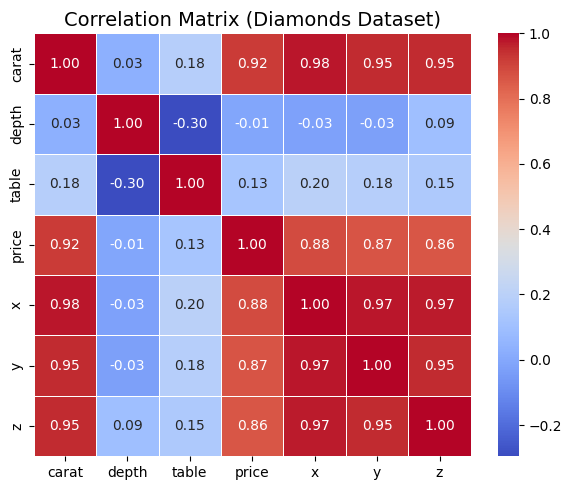

In [3]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Diamonds Dataset)", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:

features = ['carat', 'x', 'y', 'z']

### Discover relationships

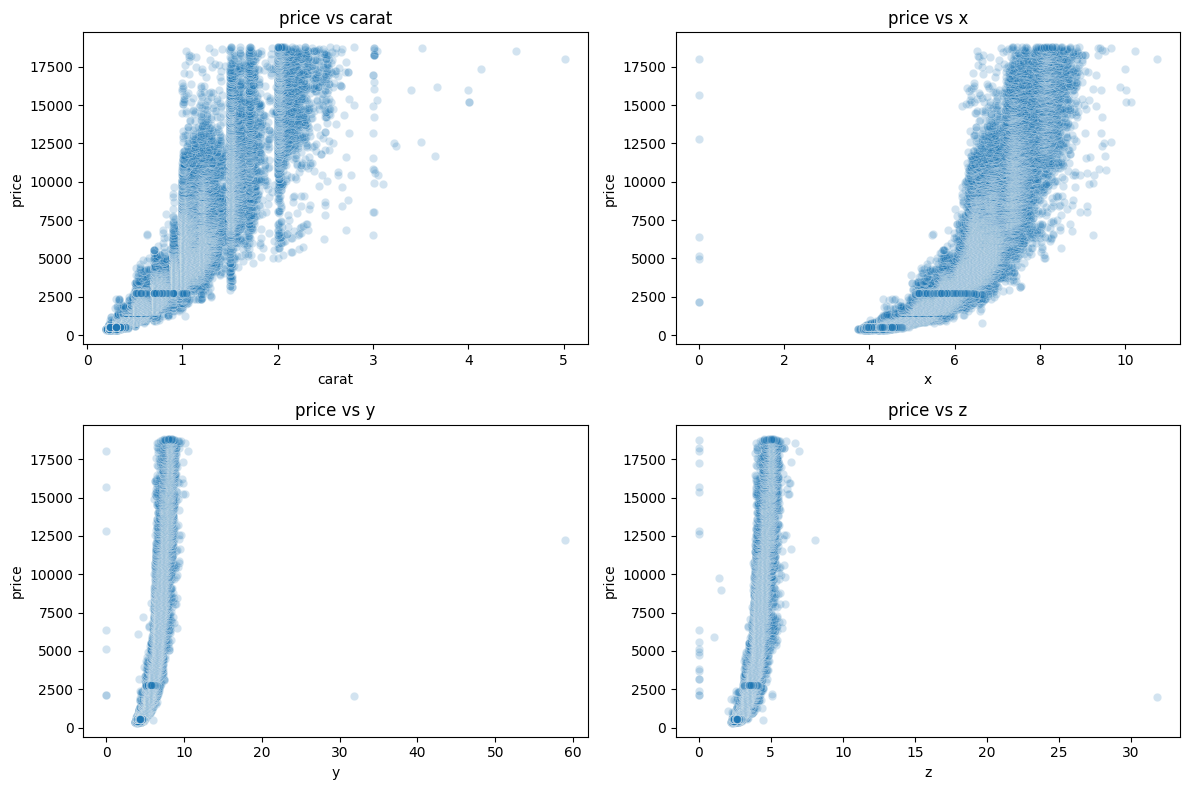

In [5]:
# Plot the price with respect to carat x, y, and z

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=feature, y='price', alpha=0.2)
    plt.title(f"price vs {feature}")

plt.tight_layout()
plt.show()

What can you notice?

### Data Cleaning

In [6]:
# Select numeric columns (features)
num_cols = df.select_dtypes(include='number').columns

# Cap outliers at 5th and 95th percentiles for each numeric column
# Loop over each feature
for col in num_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

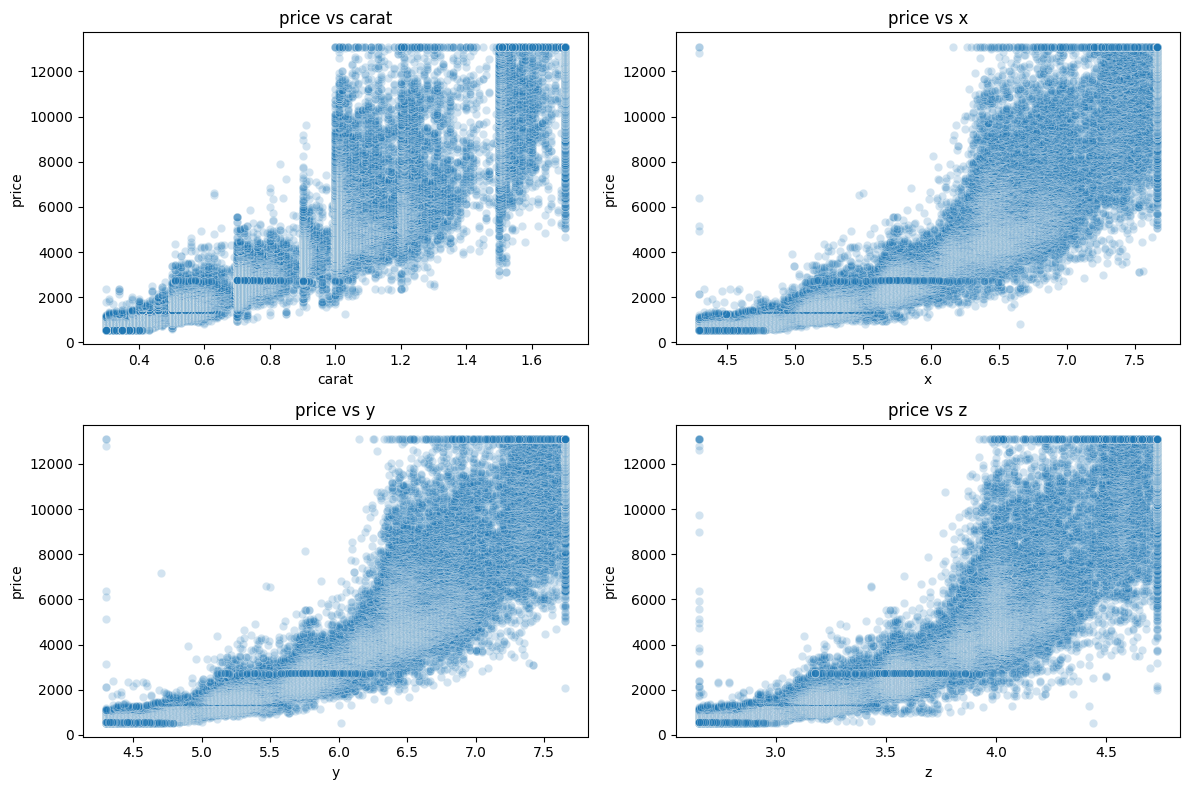

In [7]:
# Plot the price with respect to carat x, y, and z

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=feature, y='price', alpha=0.2)
    plt.title(f"price vs {feature}")

plt.tight_layout()
plt.show()

### Split Data

In [8]:
from sklearn.model_selection import train_test_split


# Access the selected features
X_selection = df[features]
y = df["price"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selection, y, test_size=0.3, random_state=42
)

# check train and test size of the input data and the target data
print('Train feature shape: ', X_train.shape)
print('Test feature shape: ',X_test.shape)
print('Train target shape: ',y_train.shape)
print('Test target shape: ',y_test.shape)

Train feature shape:  (37758, 4)
Test feature shape:  (16182, 4)
Train target shape:  (37758,)
Test target shape:  (16182,)


### Scale Data

In [14]:
from sklearn.preprocessing import StandardScaler

# Define scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply scaler on test data
X_test_scaled = scaler.transform(X_test)

# X_test_scaled

### Transform Features

In [11]:
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit the NLT on training data
X_train_tran = poly.fit_transform(X_train_scaled)

# Apply the NLT on test data
X_test_tran = poly.transform(X_test_scaled)

X_test_tran.shape

(16182, 14)

### Train Model

In [94]:
from sklearn.linear_model import LinearRegression


# Fit LR model on transformed data
model_poly = LinearRegression()
model_poly.fit(X_train_tran, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Test Model

In [95]:
# Predict
y_pred_train = model_poly.predict(X_train_tran)
y_pred_test = model_poly.predict(X_test_tran)

# check train and test prediction size
print('Train pred shape: ', y_pred_train.shape)
print('Test pred shape: ',y_pred_test.shape)

Train pred shape:  (37758,)
Test pred shape:  (16182,)


### Evaluate Model

In [96]:
from sklearn.metrics import r2_score, root_mean_squared_error

# Evaluate on Training set
r2_train = r2_score(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
print("Polynomial Regression (deg=2) -- Training Results: R² =", round(r2_train, 3), " RMSE =", round(rmse_train, 3))

# Evaluate on Testing set
r2_test = r2_score(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
print("Polynomial Regression (deg=2) -- Testing Results: R² =", round(r2_test, 3), " RMSE =", round(rmse_test, 3))


Polynomial Regression (deg=2) -- Training Results: R² = 0.891  RMSE = 1192.601
Polynomial Regression (deg=2) -- Testing Results: R² = 0.889  RMSE = 1194.585


### Compare with Linear Regression

In [97]:
# Linear model for comparison
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)

y_pred_train_lin = lin.predict(X_train_scaled)
y_pred_test_lin = lin.predict(X_test_scaled)

print('Linear Regression')
print("Train R² =", r2_score(y_train, y_pred_train_lin))
print("Test R² =", r2_score(y_test, y_pred_test_lin))


Linear Regression
Train R² = 0.8827916432871263
Test R² = 0.8824526926343127


The performance of the nonlinear model is better than the linear model.

## Exercise 1: 

Remove Multicolinearity between features.

Use only the variable that is highly correlated with the target (price) as input.

Repeat the same process.

Get model performances on train and test data.

In [98]:
features = ['carat']


In [99]:
from sklearn.model_selection import train_test_split


# Access the selected features
X_selection = df[features]
y = df["price"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selection, y, test_size=0.3, random_state=42
)

# check train and test size of the input data and the target data
print('Train feature shape: ', X_train.shape)
print('Test feature shape: ',X_test.shape)
print('Train target shape: ',y_train.shape)
print('Test target shape: ',y_test.shape)

Train feature shape:  (37758, 1)
Test feature shape:  (16182, 1)
Train target shape:  (37758,)
Test target shape:  (16182,)


In [100]:
from sklearn.preprocessing import StandardScaler

# Define scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train))

# Apply scaler on test data
X_test_scaled = pd.DataFrame(scaler.transform(X_test))

X_test_scaled.head()

,0
0,-1.133739
1,-0.475881
2,-0.898790
3,-0.828305
4,1.803127


In [101]:
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit the NLT on training data
X_train_tran = poly.fit_transform(X_train_scaled)

# Apply the NLT on test data
X_test_tran = poly.transform(X_test_scaled)

X_test_tran.shape

(16182, 2)

In [102]:
from sklearn.linear_model import LinearRegression


# Fit LR model on transformed data
model_poly = LinearRegression()
model_poly.fit(X_train_tran, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
# Predict
y_pred_train = model_poly.predict(X_train_tran)
y_pred_test = model_poly.predict(X_test_tran)

# check train and test prediction size
print('Train pred shape: ', y_pred_train.shape)
print('Test pred shape: ',y_pred_test.shape)

Train pred shape:  (37758,)
Test pred shape:  (16182,)


In [104]:
from sklearn.metrics import r2_score, root_mean_squared_error

# Evaluate on Training set
r2_train = r2_score(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
print("Polynomial Regression (deg=2) -- Training Results: R² =", round(r2_train, 3), " RMSE =", round(rmse_train, 3))

# Evaluate on Testing set
r2_test = r2_score(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
print("Polynomial Regression (deg=2) -- Testing Results: R² =", round(r2_test, 3), " RMSE =", round(rmse_test, 3))


Polynomial Regression (deg=2) -- Training Results: R² = 0.884  RMSE = 1231.14
Polynomial Regression (deg=2) -- Testing Results: R² = 0.883  RMSE = 1222.109


In [105]:
# Linear model for comparison
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)

y_pred_train_lin = lin.predict(X_train_scaled)
y_pred_test_lin = lin.predict(X_test_scaled)

print('Linear Regression')
print("Train R² =", r2_score(y_train, y_pred_train_lin))
print("Test R² =", r2_score(y_test, y_pred_test_lin))


Linear Regression
Train R² = 0.8647452021770241
Test R² = 0.8620632924149552
